In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmath

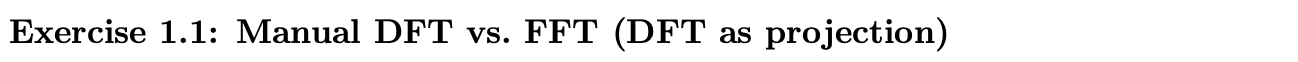
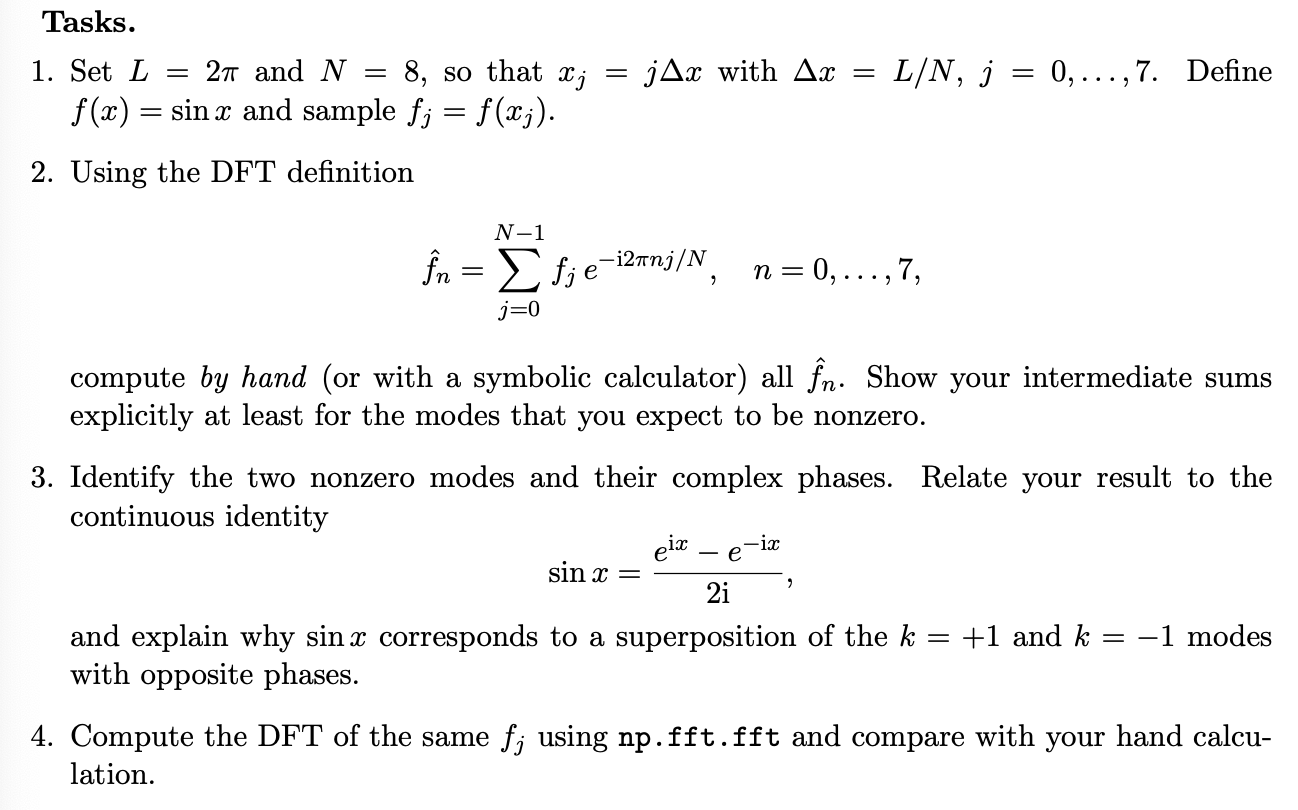

In [2]:
L = 2*np.pi
N = 8
x_j = np.zeros(N)

def f(x):
    return np.sin(x)
    
sampled_array = []

for i in range(0,N):
    x_j[i] = i*L/N

print("Grid spacing ∆x: {}".format(L/N))

sampled_array.append(list(map(lambda x: f(x), x_j)))

for i, _ in enumerate(sampled_array[0]):
    print("f_{} = {}".format(i,sampled_array[0][i]))

Grid spacing ∆x: 0.7853981633974483
f_0 = 0.0
f_1 = 0.7071067811865475
f_2 = 1.0
f_3 = 0.7071067811865476
f_4 = 1.2246467991473532e-16
f_5 = -0.7071067811865475
f_6 = -1.0
f_7 = -0.7071067811865477


In [125]:
# Computing DFT by hand

# f_hat_dft = np.zeros(N)

# (n=0) f_hat_dft[0] = 0.0 + f1 + f2 + f3 + f4 + f5 + f6 + f7 = 0

# (n=1) f_hat_dft[1] = -1.22465e-16 - 4j

# (n=2) f_hat_dft[2] = f1*e^(-i*4pi/8) + f2*e^(-i*pi) + f3*e^(-i*12pi/8)
#                     + f4*e^(-i*2pi) + f5*e^(-i*20pi/8) + f6*e^(-i*24pi/8)
#                     + f7*e^(-i*28pi/8)
#                     = 

# (n=3) f_hat_dft[3] = f1*e^(-i*6pi/8) + f2*e^(-i*12/8pi) + f3*e^(-i*18pi/8)
#                     + f4*e^(-i*3pi) + f5*e^(-i*30pi/8) + f6*e^(-i*36pi/8)
#                     + f7*e^(-i*42pi/8)
#                     = 


In [3]:
f_hat = np.fft.fft(sampled_array[0])
f_hat

array([ 1.14423775e-17+0.00000000e+00j, -4.36483172e-16-4.00000000e+00j,
        1.22464680e-16-1.11022302e-16j,  1.91553812e-16-4.44089210e-16j,
        2.33486982e-16+0.00000000e+00j,  1.91553812e-16+4.44089210e-16j,
        1.22464680e-16+1.11022302e-16j, -4.36483172e-16+4.00000000e+00j])

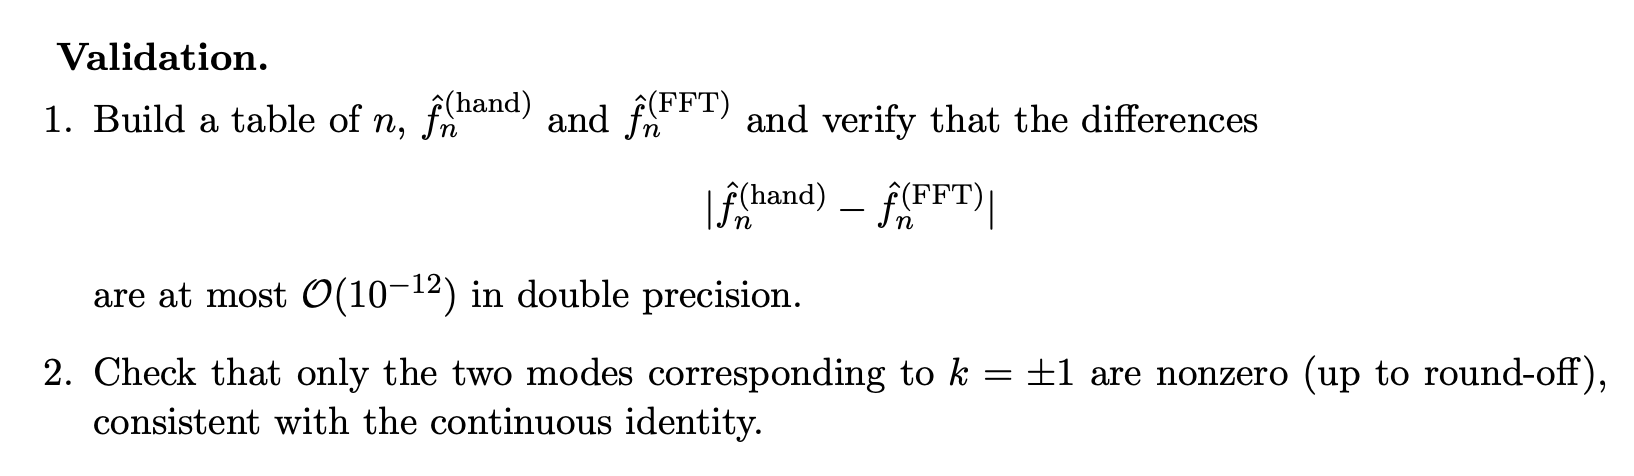

In [4]:
validation_dft = pd.DataFrame(columns = ['n','f_hat_hand','f_hat_fft'])

validation_dft.loc[len(validation_dft)] = [0, 0.0,f_hat[0]]
validation_dft.loc[len(validation_dft)] = [1, -1.22465e-16 - 4j,f_hat[1]]
validation_dft.loc[len(validation_dft)] = [2, -1.22465e-16,f_hat[2]]

validation_dft['err'] = np.abs(
    validation_dft['f_hat_hand'] - validation_dft['f_hat_fft']
                              )
validation_dft['n'] = validation_dft['n'].astype('int')

validation_dft

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/dtypes/astype.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  return arr.astype(dtype, copy=True)


,n,f_hat_hand,f_hat_fft,err
0,0,0.000000e+00+0.000000e+ 00j,1.144238e-17+0.000000e+ 00j,1.144238e-17
1,1,-1.224650e-16-4.000000e+ 00j,-4.364832e-16-4.000000e+ 00j,3.140182e-16
2,2,-1.224650e-16+0.000000e+ 00j,1.224647e-16-1.110223e- 16j,2.689173e-16


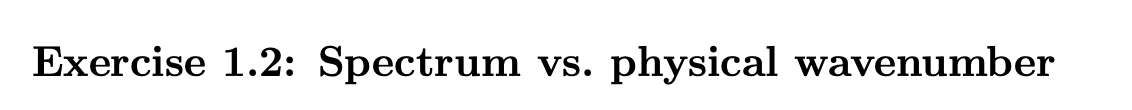
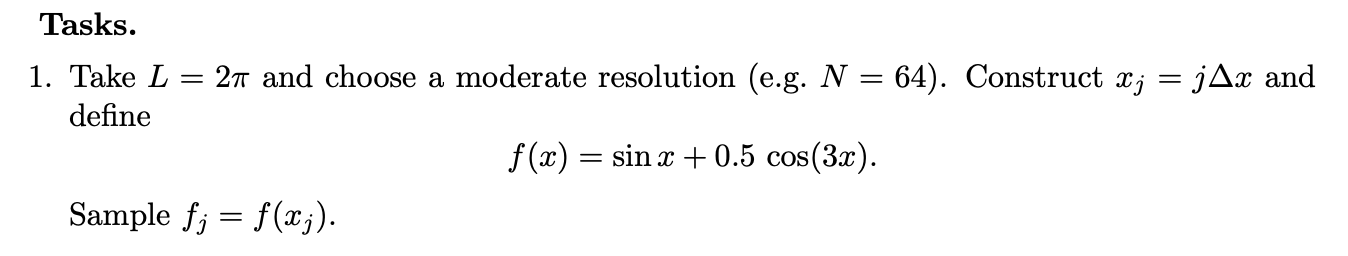
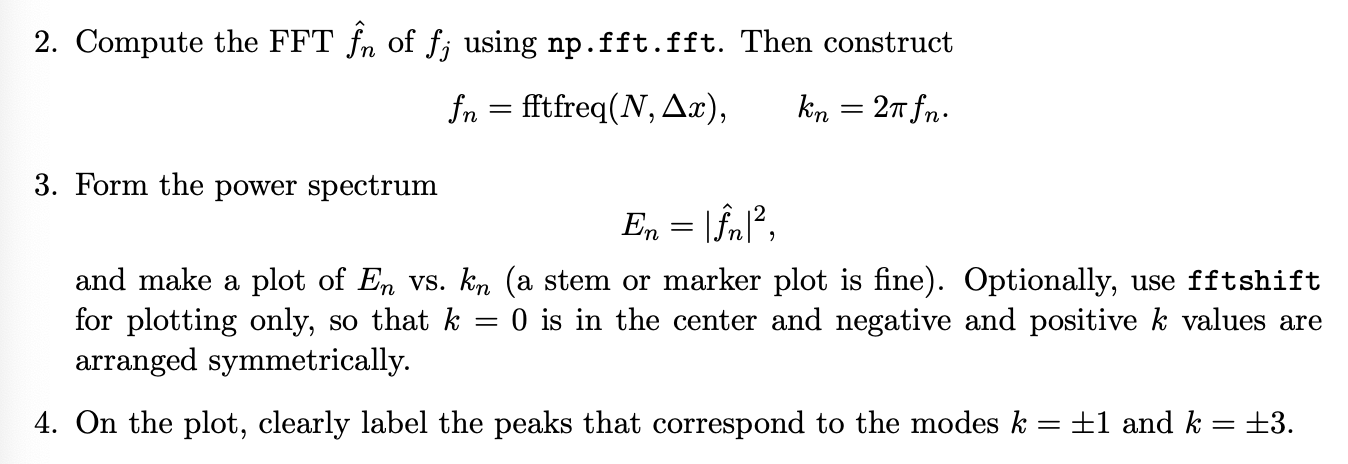

In [5]:
L = 2*np.pi
N = 64
x_j = np.zeros(N)

def f(x):
    return np.sin(x)
def g(x):
    return np.cos(3*x)
def h(x):
    return f(x) + 0.5*g(x)
    
sampled_array = []

for i in range(0,N):
    x_j[i] = i*L/N

print("Grid spacing ∆x: {}".format(L/N))

sampled_array.append(list(map(lambda x: h(x), x_j)))

Grid spacing ∆x: 0.09817477042468103


In [6]:
f_hat_n = np.fft.fft(sampled_array[0])
f_n = np.fft.fftfreq(N, L/N)
k_n = 2*np.pi*f_n
k_n

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31., -32.,
       -31., -30., -29., -28., -27., -26., -25., -24., -23., -22., -21.,
       -20., -19., -18., -17., -16., -15., -14., -13., -12., -11., -10.,
        -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.])

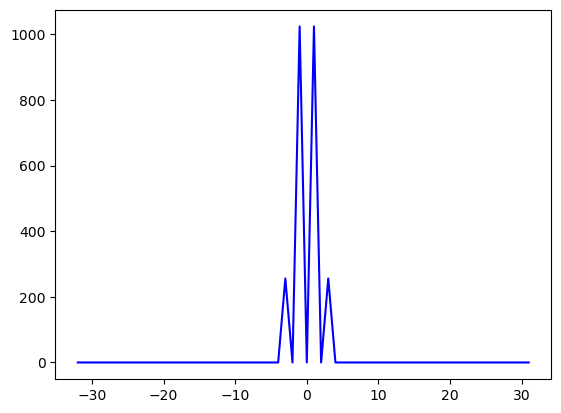

In [7]:
E_n = np.square(np.abs(np.fft.fftshift(f_hat_n)))

plt.plot(np.fft.fftshift(k_n),E_n,color = 'b')

In [8]:
idx_sorted = np.argsort(E_n)[-4:]
k_shift = np.fft.fftshift(k_n)
k_shift[idx_sorted]

array([-3.,  3.,  1., -1.])

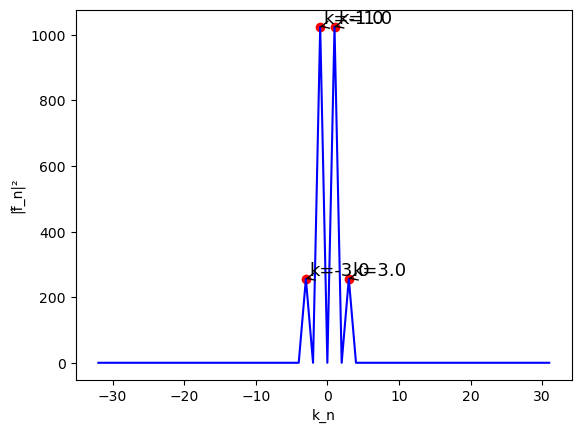

In [9]:
for k_target in [-3.,  3.,  1., -1.]:
    tid = np.where(k_shift == k_target)[0][0]
    
    plt.plot(k_shift[tid],E_n[tid],'ro')

    plt.annotate(
        f'k={k_target}',
        xy = (k_shift[tid],E_n[tid]),
        xytext=(k_shift[tid] + 0.5, E_n[tid] + 10),
        arrowprops=dict(arrowstyle='->', lw=1),
        fontsize=13
    )
plt.plot(np.fft.fftshift(k_n),E_n,color = 'b')

plt.xlabel('k_n')
plt.ylabel('|f̂_n|²')
plt.show()

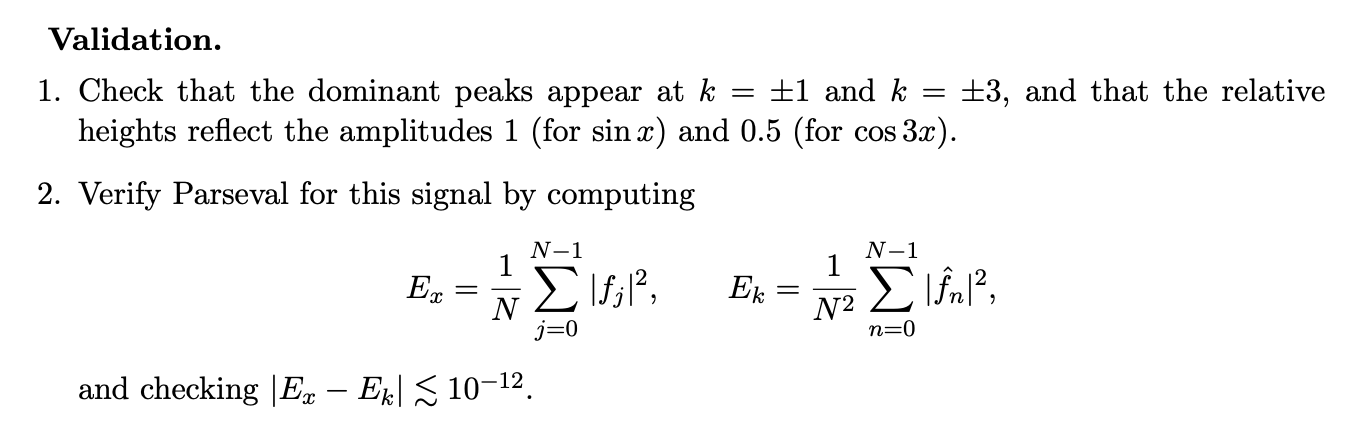

In [10]:
idx_peaks = np.argsort(E_n)[-4:]
k_shift[idx_peaks]

array([-3.,  3.,  1., -1.])

In [11]:
# Parseval Verification

E_x = (1/N)*np.sum(np.square(np.abs(sampled_array[0])))
E_k = (1/N**2)*np.sum(np.square(np.abs(f_hat_n)))

np.abs(np.subtract(E_x,E_k))

np.float64(0.0)

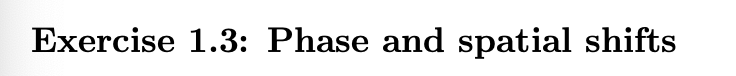
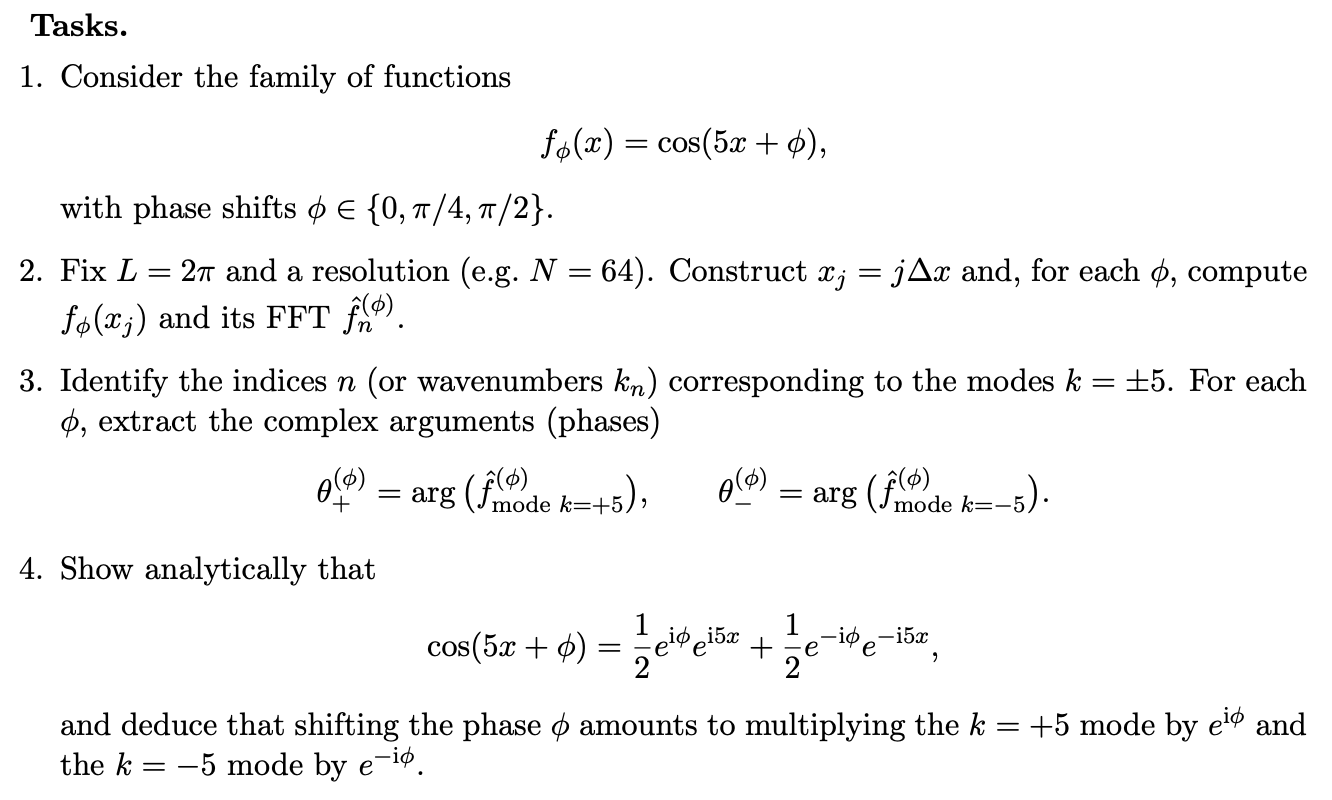

In [12]:
L = 2*np.pi
N = 64
x_j = np.zeros(N)
phase_shifts = {
    "0": 0,
    "pi/4": np.pi/4,
    "pi/2": np.pi/2
}

def f(x,phi):
    return np.cos(5*x + phi)
    
sampled_array = []

for i in range(0,N):
    x_j[i] = i*L/N

print("Grid spacing ∆x: {}".format(L/N))

sampled_per_phi = {
        i:[f(point,phi) for point in x_j] for i,phi in phase_shifts.items()
    }

Grid spacing ∆x: 0.09817477042468103


In [13]:
f_hat_n_0 = np.fft.fft(sampled_per_phi['0'])
f_hat_n_piby4 = np.fft.fft(sampled_per_phi['pi/4'])
f_hat_n_piby2 = np.fft.fft(sampled_per_phi['pi/2'])

freq = np.fft.fftfreq(N,L/N)
k_n = 2*np.pi*freq
k_n

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31., -32.,
       -31., -30., -29., -28., -27., -26., -25., -24., -23., -22., -21.,
       -20., -19., -18., -17., -16., -15., -14., -13., -12., -11., -10.,
        -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.])

In [14]:
k_shift = np.fft.fftshift(k_n)

idx_plus = np.where(k_shift == 5)[0]
idx_minus = np.where(k_shift == -5)[0]

print("Indices: ", idx_plus,idx_minus,"\n")

f_hat_n_0_shift = np.fft.fftshift(f_hat_n_0)
f_hat_n_piby4_shift = np.fft.fftshift(f_hat_n_piby4)
f_hat_n_piby2_shift = np.fft.fftshift(f_hat_n_piby2)

for f_,theta in zip([f_hat_n_0_shift,f_hat_n_piby4_shift,f_hat_n_piby2_shift],['0','pi/4','pi/2']):

    theta_plus = cmath.phase(f_[idx_plus][0])
    theta_minus = cmath.phase(f_[idx_minus][0])

    print(theta, ": Theta_plus is",theta_plus, "and Theta_minus is",theta_minus)

Indices:  [37] [27] 

0 : Theta_plus is -6.524249488635159e-16 and Theta_minus is 6.432830116239992e-16
pi/4 : Theta_plus is 0.7853981633974482 and Theta_minus is -0.7853981633974482
pi/2 : Theta_plus is 1.5707963267948961 and Theta_minus is -1.5707963267948961


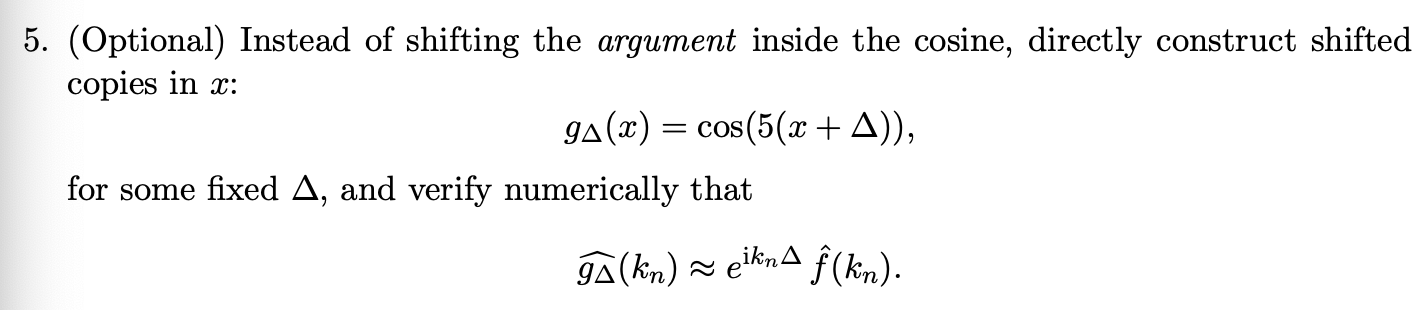

In [15]:
L = 2*np.pi
N = 64
x_j = np.zeros(N)

def g_del(x):
    return np.cos(5*(x + 0.7853981633974483)) # ∆ = pi/4 (randomly chosen)

def f(x):
    return np.cos(5*x)
    
sampled_array, sampled_array_del = [], []

for i in range(0,N):
    x_j[i] = i*L/N

print("Grid spacing ∆x: {}".format(L/N))

sampled_array_del.append([g_del(point) for point in x_j])
sampled_array.append([f(point) for point in x_j])

Grid spacing ∆x: 0.09817477042468103


In [16]:
g_del_hat = np.fft.fft(sampled_array_del[0])
g_del_hat = np.fft.fftshift(g_del_hat)
print(g_del_hat)

k_n = 2*np.pi*np.fft.fftfreq(N,L/N)
k_n = np.fft.fftshift(k_n)
k_n

[ 7.47699806e-16+0.00000000e+00j -1.57294367e-15-4.51955716e-16j
 -2.99227795e-15+2.54794882e-15j  1.08098380e-15-1.69999056e-14j
  1.30428358e-14-9.53767047e-16j -1.77635684e-15+3.55271368e-15j
  1.00343699e-14+2.48051128e-15j  4.11560970e-15+9.95942030e-15j
 -1.08293631e-14+1.85404441e-15j  5.26480637e-15+2.72021847e-15j
 -5.84633667e-15+2.24627116e-16j -3.46695506e-15+7.60307251e-15j
 -1.99455478e-16+5.59320289e-15j -1.69700713e-14-5.62077240e-15j
  3.46823236e-15-1.28376009e-14j  1.88295694e-15+4.24108185e-15j
  5.24410306e-15-2.99760217e-15j  2.73258682e-15+7.70128832e-15j
 -4.15404521e-15-2.57398872e-15j  1.45678326e-15+1.13946225e-15j
 -1.60525859e-15-8.95544035e-16j  3.55271368e-15+1.15463195e-14j
  2.19153278e-16-5.32973199e-15j -2.17926046e-15+4.28934298e-15j
 -3.60693774e-15-7.54979693e-16j  3.85576039e-15+1.42150151e-15j
 -9.48361140e-16+2.24162349e-15j -2.26274170e+01+2.26274170e+01j
 -7.95222378e-16+1.21722562e-15j  4.99273542e-15+2.67760802e-15j
 -5.10980504e-15-9.824095

array([-32., -31., -30., -29., -28., -27., -26., -25., -24., -23., -22.,
       -21., -20., -19., -18., -17., -16., -15., -14., -13., -12., -11.,
       -10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.])

In [17]:
f_hat_n = np.fft.fftshift(np.fft.fft(sampled_array[0]))
rhs = np.fft.fftshift(np.exp(k_n*0.5j)*f_hat_n)
rhs

array([-2.79113609e-15+0.00000000e+00j, -9.53788563e-16+2.91997433e-15j,
       -9.96727102e-16-2.73499272e-15j, -5.16155653e-16-4.87521835e-15j,
       -7.21300446e-16-4.08734184e-15j, -2.56365957e+01+1.91511086e+01j,
       -5.94910262e-15+2.67919162e-16j, -4.69986291e-15-2.10769684e-15j,
       -3.94446376e-15-3.21251622e-15j,  5.66684081e-15-1.58736007e-15j,
        1.73852792e-15-4.97253155e-15j, -5.06606213e-16+7.34977441e-15j,
        1.11423463e-15+2.23969551e-15j, -2.37086287e-15+1.06768514e-16j,
       -4.02912885e-17-2.51457705e-15j, -5.94375829e-16-5.64336858e-16j,
        1.84009011e-15-1.16186621e-15j,  6.76186280e-15-1.15659146e-15j,
       -1.76278638e-15+7.93166092e-15j, -1.44149781e-14-3.92895085e-15j,
        6.84912559e-15-5.56105368e-15j, -4.75951004e-16-1.44925659e-15j,
       -6.36885783e-15-1.03886169e-15j,  1.04452092e-14-1.91442898e-15j,
       -6.19277277e-15+6.63819899e-15j,  3.28505678e-15-1.12139460e-15j,
       -2.81680707e-17+1.61364331e-15j, -5.48738680

In [18]:
val_table = pd.DataFrame(columns = ['lhs','rhs','Numerical verification'])

for lhs_, rhs_ in zip(g_del_hat, rhs):
    val_table.loc[len(val_table)] = [lhs_, rhs_,0]
    
val_table['Numerical verification'] = val_table.apply(
        lambda x: True if np.abs(np.subtract(x['lhs'], x['rhs'])) <= 1e-12 else False, axis=1)

In [19]:
val_table

,lhs,rhs,Numerical verification
0,7.476998e-16+0.000000e+ 00j,-2.791136e-15+0.000000e+ 00j,True
1,-1.572944e-15-4.519557e- 16j,-9.537886e-16+2.919974e- 15j,True
2,-2.992278e-15+2.547949e- 15j,-9.967271e-16-2.734993e- 15j,True
3,1.080984e-15-1.699991e- 14j,-5.161557e-16-4.875218e- 15j,True
4,1.304284e-14-9.537670e- 16j,-7.213004e-16-4.087342e- 15j,True
...,...,...,...
59,0.000000e+00-5.329071e- 15j,-2.563660e+01-1.915111e+ 01j,False
60,1.304284e-14+9.537670e- 16j,-7.213004e-16+4.087342e- 15j,True
61,1.224514e-15+1.775050e- 14j,1.090623e-15+3.706519e- 15j,True
62,-2.992278e-15-2.547949e- 15j,-9.967271e-16+2.734993e- 15j,True


In [20]:
val_table[val_table['Numerical verification'] == False].iloc[0]['lhs'].real

np.float64(-1.7763568394002505e-15)

In [21]:
val_table[val_table['Numerical verification'] == False].iloc[0]['rhs'].real

np.float64(-25.636595697501864)

In [22]:
val_table[val_table['Numerical verification'] == False]

,lhs,rhs,Numerical verification
5,-1.776357e-15+3.552714e- 15j,-2.563660e+01+1.915111e+ 01j,False
27,-2.262742e+01+2.262742e+ 01j,-5.487387e-15+1.851495e- 15j,False
37,-2.262742e+01-2.262742e+ 01j,-4.834634e-15-3.578352e- 15j,False
59,0.000000e+00-5.329071e- 15j,-2.563660e+01-1.915111e+ 01j,False


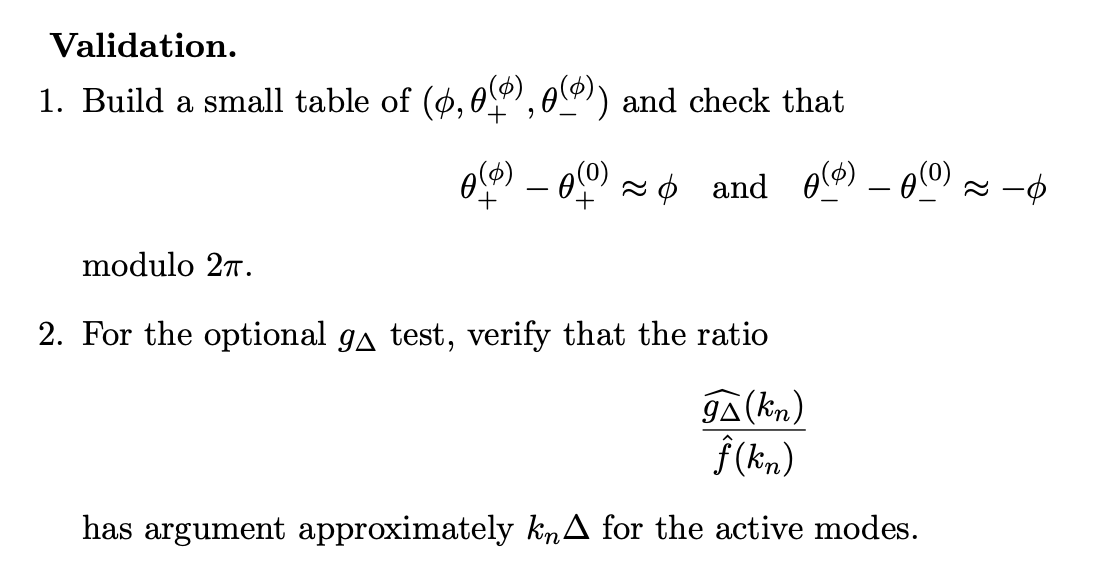

In [25]:
val_theta_phi = pd.DataFrame(columns = ['phi','theta_plus','theta_minus'])

for f_,phi in zip([f_hat_n_0_shift,f_hat_n_piby4_shift,f_hat_n_piby2_shift],['0','pi/4','pi/2']):

    theta_plus = cmath.phase(f_[idx_plus][0])
    theta_minus = cmath.phase(f_[idx_minus][0])

    val_theta_phi.loc[len(val_theta_phi)] = [phi,theta_plus,theta_minus]

    

In [26]:
val_theta_phi['delta_plus'] = val_theta_phi['theta_plus'] - pd.Series(np.repeat(val_theta_phi['theta_plus'].iloc[0],3))
val_theta_phi['delta_minus'] = val_theta_phi['theta_minus'] - pd.Series(np.repeat(val_theta_phi['theta_minus'].iloc[0],3))


val_theta_phi['rhs_plus'] = pd.Series([0,np.pi/4, np.pi/2]) % (2*np.pi)
val_theta_phi['rhs_minus'] = - pd.Series([0,np.pi/4, np.pi/2]) % pd.Series(np.repeat(2*np.pi,3))

val_theta_phi['val_plus'] = np.abs(val_theta_phi['delta_plus'] - val_theta_phi['rhs_plus'])
val_theta_phi['val_minus'] = np.abs(val_theta_phi['delta_minus'] - val_theta_phi['rhs_minus'])


In [27]:
val_theta_phi

,phi,theta_plus,theta_minus,delta_plus,delta_minus,rhs_plus,rhs_minus,val_plus,val_minus
0,0,-6.524249e-16,6.432830e-16,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
1,pi/4,7.853982e-01,-7.853982e-01,0.785398,-0.785398,0.785398,5.497787,5.551115e-16,6.283185
2,pi/2,1.570796e+00,-1.570796e+00,1.570796,-1.570796,1.570796,4.712389,2.220446e-16,6.283185


In [28]:
val_2 = pd.DataFrame(columns = ['ratio'])
val_2['ratio'] = pd.Series(g_del_hat/f_hat_n)
val_2['arg_ratio'] = np.angle(val_2['ratio'])
val_2['delta'] = val_2['arg_ratio'] - k_n*np.pi/4

In [29]:
val_2

,ratio,arg_ratio,delta
0,-0.180118-0.000000j,-3.141593,21.991149
1,0.079703-0.348180j,-1.345760,23.001583
2,-0.222555+0.547095j,1.957146,25.519091
3,-0.926892+1.186202j,2.234089,25.010636
4,-1.343043+1.476994j,2.308731,24.299879
...,...,...,...
59,-0.875826+0.282245j,2.829840,-18.375910
60,-1.343043-1.476994j,-2.308731,-24.299879
61,-0.855050-1.104417j,-2.229613,-25.006159
62,-0.222555-0.547095j,-1.957146,-25.519091
